# MIDI Preprocessing Pipeline

This notebook demonstrates the complete preprocessing pipeline:
1. Parse raw MIDI files into note events
2. Convert to piano-roll or token-based representation
3. Normalize timing resolution (16 steps per bar)
4. Segment into fixed-length windows
5. Create train/val/test splits

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))

from src.config import (
    RAW_MIDI_DIR, PROCESSED_DIR, SPLIT_DIR,
    SEQUENCE_LENGTH, TRAIN_RATIO, VAL_RATIO, TEST_RATIO, RANDOM_SEED,
    GENRES, GENRE_TO_ID, NUM_PITCHES,
)
from src.preprocessing.midi_parser import parse_midi_directory, save_parsed_data, load_parsed_data
from src.preprocessing.tokenizer import notes_to_tokens, segment_tokens, build_dataset_from_parsed
from src.preprocessing.piano_roll import (
    notes_to_piano_roll, segment_piano_roll, build_piano_roll_dataset
)

print('Modules loaded successfully.')

Modules loaded successfully.


## Step 1: Parse Raw MIDI Files

Place your MIDI files in `data/raw_midi/` organized by genre:
```
data/raw_midi/
├── classical/
├── jazz/
├── rock/
├── pop/
└── electronic/
```

In [2]:
# Parse all MIDI files from the raw directory
parsed_data = []

for genre in GENRES:
    genre_dir = os.path.join(RAW_MIDI_DIR, genre)
    if os.path.exists(genre_dir):
        genre_data = parse_midi_directory(genre_dir, genre_label=genre)
        parsed_data.extend(genre_data)
        print(f'{genre}: {len(genre_data)} files parsed')
    else:
        print(f'{genre}: directory not found at {genre_dir}')

# Also parse any files in the root raw_midi directory
if os.path.exists(RAW_MIDI_DIR):
    root_data = parse_midi_directory(RAW_MIDI_DIR)
    # Avoid duplicates
    existing_paths = {r['path'] for r in parsed_data}
    new_data = [r for r in root_data if r['path'] not in existing_paths]
    parsed_data.extend(new_data)
    if new_data:
        print(f'Root directory: {len(new_data)} additional files')

print(f'\nTotal: {len(parsed_data)} MIDI files parsed')

d:\Multi-Genre Music Generation\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


classical: 59 files parsed
jazz: 60 files parsed
rock: 59 files parsed
pop: 58 files parsed
electronic: 60 files parsed

Total: 296 MIDI files parsed


In [3]:
# Save parsed data
os.makedirs(PROCESSED_DIR, exist_ok=True)
save_parsed_data(parsed_data, os.path.join(PROCESSED_DIR, 'parsed_midi.json'))
print(f'Saved parsed data to {PROCESSED_DIR}/parsed_midi.json')

# Show summary
if parsed_data:
    total_notes = sum(r['num_notes'] for r in parsed_data)
    total_duration = sum(r['duration_sec'] for r in parsed_data)
    genres_found = set(r['genre'] for r in parsed_data)
    print(f'Total notes: {total_notes:,}')
    print(f'Total duration: {total_duration/60:.1f} minutes')
    print(f'Genres: {genres_found}')

Saved parsed data to d:\Multi-Genre Music Generation\data\processed/parsed_midi.json
Total notes: 983,509
Total duration: 1161.7 minutes
Genres: {'classical', 'electronic', 'rock', 'pop', 'jazz'}


## Step 2: Visualize MIDI Data

Piece: Bach Johann Sebastian - 2-Part Invention No. 1 in C major, BWV 772.4.mid
Genre: classical
Notes: 533
Duration: 51.5s
Piano roll shape: (824, 128)


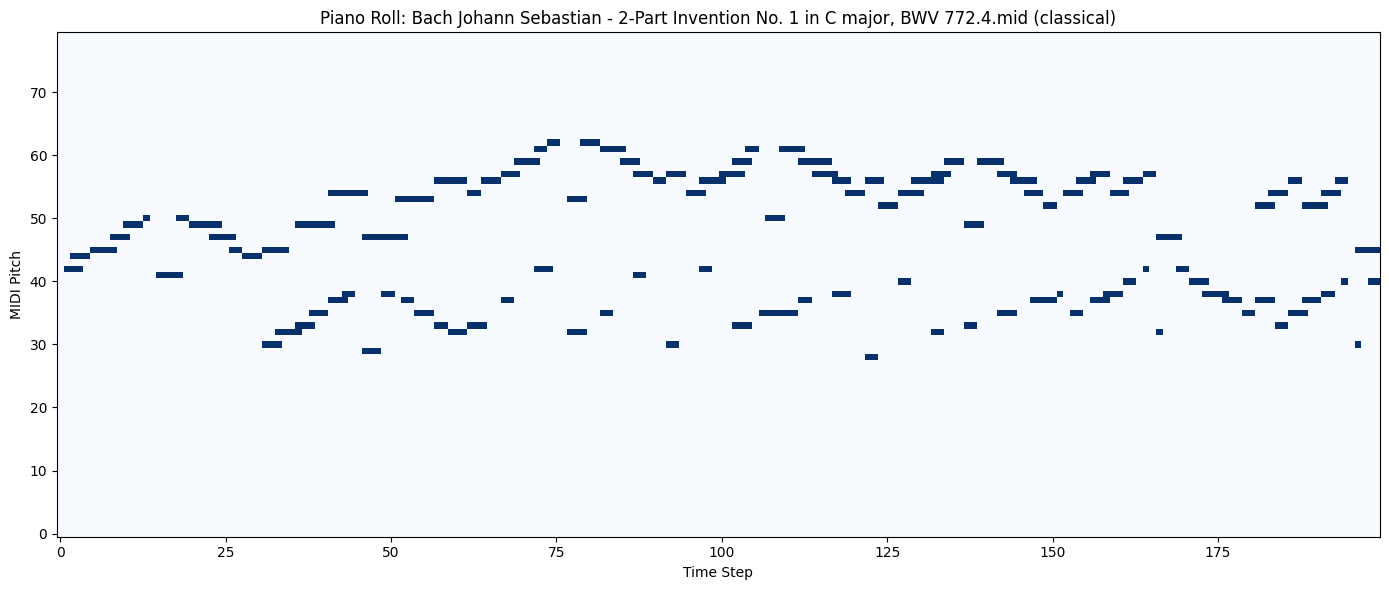

In [4]:
# Visualize the first parsed piece as a piano roll
if parsed_data:
    sample = parsed_data[0]
    print(f'Piece: {sample["filename"]}')
    print(f'Genre: {sample["genre"]}')
    print(f'Notes: {sample["num_notes"]}')
    print(f'Duration: {sample["duration_sec"]:.1f}s')

    # Create piano roll
    roll = notes_to_piano_roll(sample['notes'])
    print(f'Piano roll shape: {roll.shape}')

    # Plot first 200 steps
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(roll[:200, 20:100].T, aspect='auto', origin='lower', cmap='Blues')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('MIDI Pitch')
    ax.set_title(f'Piano Roll: {sample["filename"]} ({sample["genre"]})')
    plt.tight_layout()
    plt.show()
else:
    print('No MIDI files found. Please add MIDI files to data/raw_midi/')

## Step 3: Tokenization

In [5]:
# Demonstrate tokenization on first piece
if parsed_data:
    sample_notes = parsed_data[0]['notes'][:50]  # First 50 notes
    tokens = notes_to_tokens(sample_notes)
    print(f'First 50 notes → {len(tokens)} tokens')
    print(f'Token sample: {tokens[:30]}')

    # Segment tokens
    segments = segment_tokens(tokens, seq_len=SEQUENCE_LENGTH)
    print(f'\nSegmented into {len(segments)} sequences of length {SEQUENCE_LENGTH}')

First 50 notes → 238 tokens
Token sample: [1, 292, 65, 278, 292, 193, 67, 280, 293, 195, 292, 68, 282, 293, 196, 292, 70, 277, 293, 198, 292, 72, 277, 292, 200, 292, 73, 284, 292, 201]

Segmented into 7 sequences of length 64


## Step 4: Build Datasets

In [6]:
if parsed_data:
    # Token-based dataset (for Transformer)
    token_dataset = build_dataset_from_parsed(parsed_data, seq_len=SEQUENCE_LENGTH)
    print(f'Token dataset: {len(token_dataset)} sequences')

    # Piano-roll dataset (for AE and VAE)
    pr_dataset = build_piano_roll_dataset(parsed_data, seg_len=SEQUENCE_LENGTH)
    print(f'Piano-roll dataset: {len(pr_dataset)} segments')

    # Show sample
    sample_item = token_dataset[0]
    print(f'\nToken sample shape: {sample_item["tokens"].shape}')
    print(f'Genre ID: {sample_item.get("genre", "N/A")}')
else:
    print('No data available for dataset building.')

Token dataset: 129139 sequences
Piano-roll dataset: 34702 segments

Token sample shape: torch.Size([64])
Genre ID: 0


## Step 5: Train / Validation / Test Split

In [7]:
import torch
from torch.utils.data import random_split

if parsed_data:
    dataset = build_piano_roll_dataset(parsed_data, seg_len=SEQUENCE_LENGTH)
    total = len(dataset)

    train_size = int(TRAIN_RATIO * total)
    val_size = int(VAL_RATIO * total)
    test_size = total - train_size - val_size

    train_set, val_set, test_set = random_split(
        dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(RANDOM_SEED)
    )

    print(f'Total samples: {total}')
    print(f'Train: {len(train_set)} ({TRAIN_RATIO*100:.0f}%)')
    print(f'Val:   {len(val_set)} ({VAL_RATIO*100:.0f}%)')
    print(f'Test:  {len(test_set)} ({TEST_RATIO*100:.0f}%)')

    # Save split indices
    os.makedirs(SPLIT_DIR, exist_ok=True)
    split_info = {
        'train_indices': train_set.indices,
        'val_indices': val_set.indices,
        'test_indices': test_set.indices,
    }
    with open(os.path.join(SPLIT_DIR, 'split_indices.json'), 'w') as f:
        json.dump(split_info, f)
    print(f'Split indices saved to {SPLIT_DIR}/split_indices.json')
else:
    print('No data to split.')

Total samples: 34702
Train: 27761 (80%)
Val:   3470 (10%)
Test:  3471 (10%)
Split indices saved to d:\Multi-Genre Music Generation\data\train_test_split/split_indices.json


## Summary

The preprocessing pipeline is complete. The following files are ready:
- `data/processed/parsed_midi.json` — Parsed note events
- `data/train_test_split/split_indices.json` — Dataset split indices

Next steps:
- Run `python -m src.training.train_ae` for Task 1 (LSTM Autoencoder)
- Run `python -m src.training.train_vae` for Task 2 (VAE)
- Run `python -m src.training.train_transformer` for Task 3 (Transformer)